# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('air_fryers_clean_brand_year.csv')

In [ ]:
# Q-1-1

# Task 1: Verify 10 brands and years 2019-2023
num_brands = df['brand'].nunique()
years_covered = sorted(df['year'].unique())

print(f"Number of unique brands: {num_brands}")
print(f"Years in dataset: {years_covered}")

Number of unique brands: 10
Years in dataset: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


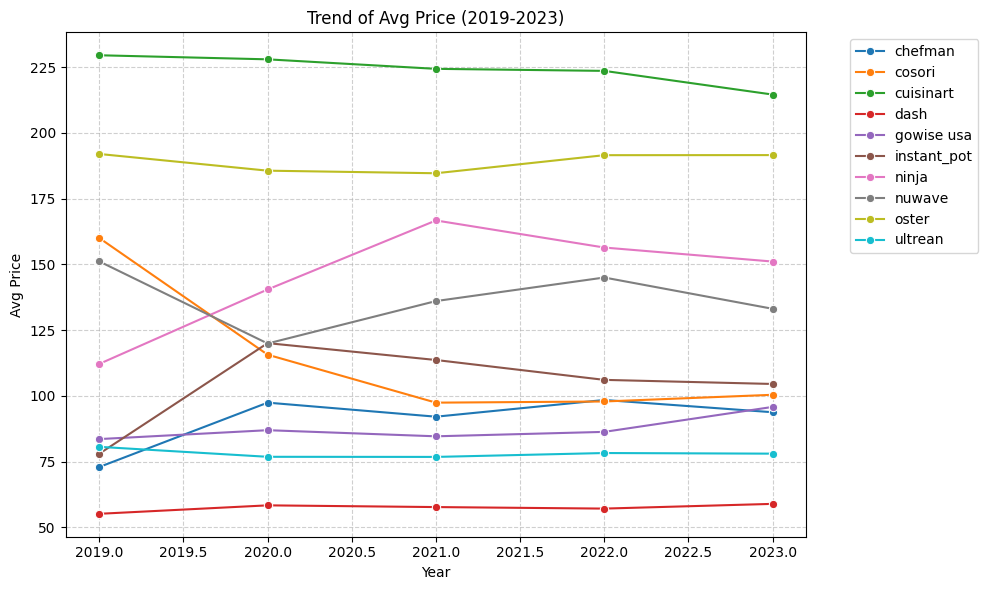

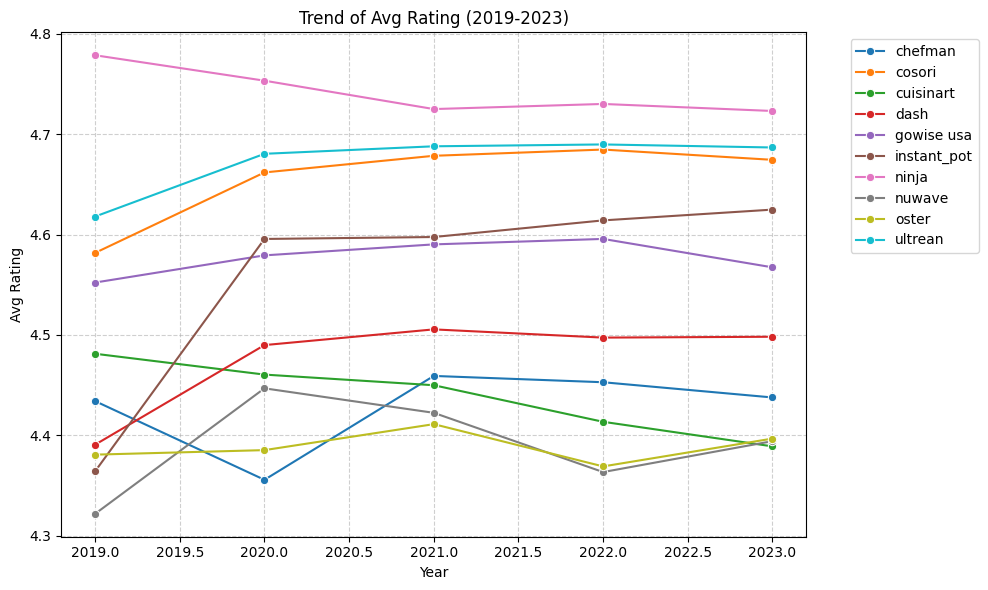

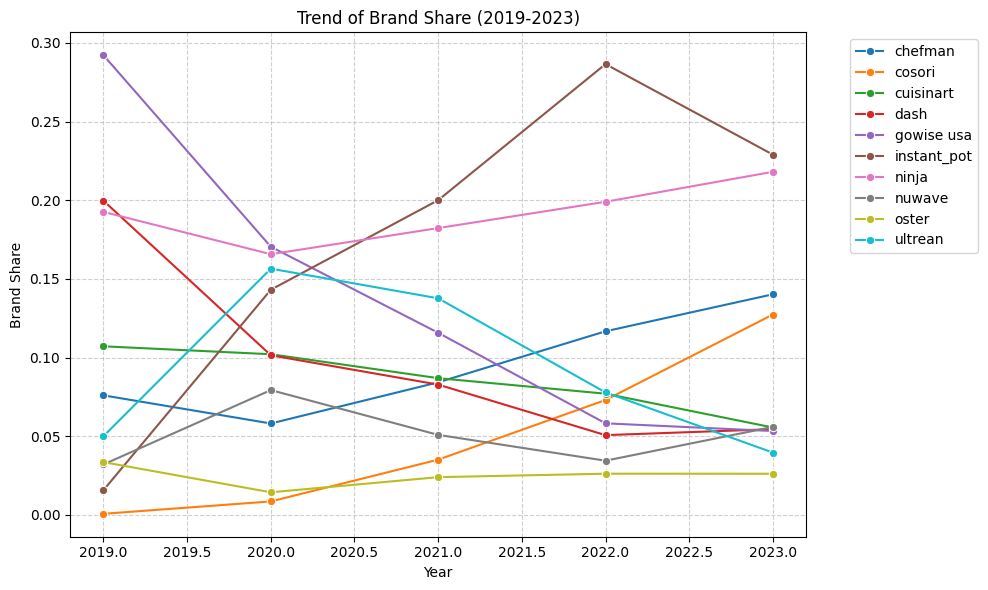

In [ ]:
# Q-1-2

# --- Task 2: Plot trends over time by brand ---
metrics = ['avg_price', 'avg_rating', 'brand_share']

for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x='year', y=metric, hue='brand', marker='o')
    plt.title(f'Trend of {metric.replace("_", " ").title()} (2019-2023)')
    plt.ylabel(metric.replace("_", " ").title())
    plt.xlabel('Year')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [ ]:
#Q-1-3

# --- Task 3: Summarize Product Characteristics ---
# List of characteristic share columns
char_cols = ['compact_share', 'dual_basket_share', 'oven_style_share',
             'rotisserie_share', 'window_share']

# Calculate mean share across all observations
avg_characteristics = df[char_cols].mean().sort_values(ascending=False)
print("\nAverage Product Characteristic Shares across the market:")
print(avg_characteristics)

# Pivot to see which brands specialize in which features
brand_specialization = df.groupby('brand')[char_cols].mean()
print("\nCharacteristic specialization by Brand (Mean Share):")
print(brand_specialization)


Average Product Characteristic Shares across the market:
compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260
dtype: float64

Characteristic specialization by Brand (Mean Share):
             compact_share  dual_basket_share  oven_style_share  \
brand                                                             
chefman           0.961595           0.013462          0.596962   
cosori            0.996784           0.000000          0.029952   
cuisinart         0.995902           0.000000          0.913059   
dash              0.999481           0.000000          0.890098   
gowise usa        0.999877           0.000000          0.183790   
instant_pot       0.859655           0.000030          0.674784   
ninja             0.992084           0.002488          0.100477   
nuwave            0.995431           0.006622          0.542646   
oster             1.000000           0.000000        

# Answer to Q-1-3

The most dominant feature is compact_share, with a market-wide average of approximately 98%. This suggests that nearly every product in this top-10 dataset is categorized as 'compact'. The second most common feature is oven_style_share at 56.3%. This indicates that more than half of the air fryers produced by these brands follow the oven-style design rather than the traditional basket-only design.


The most rare features are dual_basket_share (0.2%),
window_share (3.7%), and rotisserie_share (7.1%).


Several brands focus heavily on the oven-style form factor: Cuisinart (91.3%),Dash (89.0%), Oster (86.4%), Ultrean (83.0%). These brands have moved away from the "standard" basket design and focus on the countertop oven aesthetic.

Chefman stands out as the most diversified brand in terms of features. Chefman specializes in the rarer features: window_share (36.3%), suggesting it is the go-to brand for users who want to see their food cooking. It also is the highest rotisserie_share (37.0%), nearly double its closest competitor.

Cosori and Ninja appear to be in the "Standard Basket". Cosori has a very low oven_style_share (3.0%), meaning 97% of its products are likely traditional basket fryers. Ninja similarly keeps a low oven_style_share (10.0%) and avoids the rotisserie and window features almost entirely.

# Answer to Q-1-4

The air fryer market from 2019–2023 appears to be characterized by high product differentiation and significant shifts in leadership, suggesting a dynamic and competitive landscape rather than a stable one. Cuisinart is consistently the most expensive brand, maintaining a price point above $200, followed by Oster and Ninja. Interestingly, these expensive brands tend to specialize in "Oven-Style" models. In terms of Lareg-Share-Brands, market leadership has shifted dramatically. While GoWise USA started with the largest share in 2019, it has since declined. As of 2023, Instant Pot and Ninja have emerged as the dominant players, each holding roughly 20–25% of the market share. Cosori has also shown aggressive growth, moving from nearly 0% to a top-tier position. The market does not look stable over time. We see "churn" in brand dominance, with early leaders losing ground to newer entrants like Instant Pot and Cosori. Pricing is also volatile; for instance, Ninja’s average price saw a significant spike in 2021 before tapering off, and NuWave experienced a sharp price drop followed by a recovery. These fluctuations in both price and share indicate a market still searching for equilibrium as brands experiment with different feature sets—like Chefman’s focus on windows and rotisseries—to capture consumer interest.


## 2. Demand Estimation

We will estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

Here:

- $b$ indexes brands
- $t$ indexes years
- $s_{bt}$ is `brand_share`
- $p_{bt}$ is `avg_price`
- $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristics
- $\alpha_t$ are year dummy coefficients
- $\gamma_b$ are brand dummy coefficients
- $\beta_{price}$ is **one constant price coefficient**, shared by all brands and all years

That last point matters: do **not** estimate a different price coefficient for every brand-year. We do not have enough information for that, and it would make the cost calculation impossible to interpret.

Use `pd.get_dummies(..., drop_first=True)` for brand and year dummies. The dropped brand and dropped year become the reference categories, so all dummy coefficients are interpreted relative to those omitted categories.

Questions:

1. What is the estimated price coefficient, $\hat{\beta}_{price}$?
2. Is it negative? Why is that important?
3. Which product features are associated with higher demand?
4. Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.
5. Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.
6. What is the model's $R^2$?

This part of the work is the **data scientist** role: turning the cleaned data into a model that can be used for prediction and interpretation.

In [ ]:
#Q-2-1

# import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Create the dependent variable (log of brand share)
# Note: ensure there are no zero shares before taking the log,
# or you will get -inf values.
y = np.log(df['brand_share'])

# 2. Create dummy variables for brand and year
# drop_first=True prevents perfect multicollinearity (the dummy variable trap)
df_dummies = pd.get_dummies(df, columns=['brand', 'year'], drop_first=True)

# 3. Define the independent variables (X)
# Replace the list below with your actual product characteristic column names
product_features = [
    'compact_share',
    'dual_basket_share',
    'oven_style_share',
    'rotisserie_share',
    'window_share'
]

# Select our core variables + the generated dummies + product features
# Note: df_dummies contains the original columns PLUS the new dummy columns,
# but minus the original 'brand' and 'year' columns.
features_to_include = ['avg_price', 'avg_rating'] + product_features
dummy_cols = [col for col in df_dummies.columns if col.startswith('brand_') or col.startswith('year_')]

X = df_dummies[features_to_include + dummy_cols]

# Ensure all data in X is numeric (boolean dummies should be cast to float/int)
X = X.astype(float)

# 4. Add a constant (for alpha_0 in your equation)
X = sm.add_constant(X)

# 5. Fit the OLS (Ordinary Least Squares) model
model = sm.OLS(y, X).fit()

# 6. Print the results to answer your questions
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            brand_share   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     10.91
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           1.52e-08
Time:                        19:10:47   Log-Likelihood:                -17.052
No. Observations:                  50   AIC:                             78.10
Df Residuals:                      28   BIC:                             120.2
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -5.8414     11.31

# Answer to Q-2-1

The estimated price coefficient is −0.0267.

# Answer to Q-2-2

Yes, it is negative. This is important because it aligns with the Law of Demand. A negative coefficient indicates an inverse relationship: as the price of the product increases, the market share decreases (holding all other factors constant). Statistically, this is highly significant in your model with a p-value of 0.002, which is well below the standard 0.05 threshold.

# Answer to Q-2-3

To find the features associated with higher demand, we need to look at positive coefficients:

**Dual Basket Share:** Has the largest positive impact with a coefficient of 12.1955.

**Compact Share:** Coefficient of 1.5448.

**Rotisserie Share:** Coefficient of 1.3326.



While these have positive coefficients, their p-values (all >0.5) suggest they are not "statistically significant" in this specific model. However, based purely on the direction of the coefficient, dual_basket_share is the strongest predictor of higher demand among features.

# Answer to Q-2-4

The brand coefficients are interpreted relative to the "dropped" brand:

**Brand Cuisinart:** This is the largest brand effect with a coefficient of 3.7536. It is also the only brand dummy that is statistically significant (p = 0.042).

**Brand Oster:** The next largest with a coefficient of 2.2191.

# Answer to Q-2-5

The year coefficients represent the baseline demand relative to the dropped year (likely 2019).

**Year 2021:** This year has the largest coefficient at 0.5052.

**Year 2023:** The next largest at 0.4449.

**Year 2022:** Close behind at 0.4379.

Demand appears to have peaked in 2021 and remained relatively stable (and higher than the base year) through 2023.

# Answer to Q-2-6

The R^2 is 0.891. This means that approximately 89.1% of the variance in brand share is explained by the variables included in your model, indicating a very strong fit for the data.

#

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

Question 1:
Markups are fairly compressed across brands ($38–$46), meaning price differences mostly reflect cost differences. Cuisinart has the highest average unit cost ($183) and Dash the lowest ($16). Ninja and Instant Pot lead on share-weighted average profit.

Question 2:
There are no negative unit costs in this data. If there were, it would signal a misspecified model — likely a positive (wrong-sign) price coefficient, which would cause the denominator in the markup formula to flip sign and push inferred costs below zero.

Question 3:
 The highest average unit costs belong to Cuisinart (~$183), Oster ($151), and Ninja ($99). Price and unit cost are strongly positively correlated — more expensive products really do cost more to make. However, the relationship between rating and unit cost is weak. Higher-cost brands don't consistently receive better reviews, suggesting consumers don't always perceive quality commensurate with price.

Question 4:


Question 5:
Ninja leads with an average profit index of ~8.91, followed closely by Instant Pot (~8.49) and GoWise USA (~6.50). Oster (~0.96) brings up the rear despite having a high price — its very low market share drags down its share-weighted profit. This tells you that in this market, volume (share) matters as much as margin.


In [2]:
# Q3 - Setup: re-run Q2 model, then compute demand slope, unit cost, markup, average profit

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('air_fryers_clean_brand_year.csv')

# Rebuild the Q2 model
y = np.log(df['brand_share'])
df_dummies = pd.get_dummies(df, columns=['brand', 'year'], drop_first=True)

product_features = ['compact_share', 'dual_basket_share', 'oven_style_share', 'rotisserie_share', 'window_share']
features_to_include = ['avg_price', 'avg_rating'] + product_features
dummy_cols = [col for col in df_dummies.columns if col.startswith('brand_') or col.startswith('year_')]

X = df_dummies[features_to_include + dummy_cols].astype(float)
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

beta_price = model.params['avg_price']
print(f"beta_price = {beta_price:.6f}")

# Q3 computations
df['demand_slope']   = beta_price * df['brand_share'] * (1 - df['brand_share'])
df['unit_cost']      = df['avg_price'] + df['brand_share'] / df['demand_slope']
df['markup']         = df['avg_price'] - df['unit_cost']
df['average_profit'] = df['brand_share'] * df['markup']

print("\nNew columns added successfully:")
print(df[['brand', 'year', 'avg_price', 'unit_cost', 'markup', 'average_profit']].round(3))

beta_price = -0.026674

New columns added successfully:
          brand  year  avg_price  unit_cost  markup  average_profit
0       chefman  2019     72.964     32.390  40.573           3.084
1        cosori  2019    159.990    122.473  37.517           0.027
2     cuisinart  2019    229.465    187.475  41.990           4.501
3          dash  2019     55.176      8.331  46.845           9.356
4    gowise usa  2019     83.576     30.611  52.965          15.476
5   instant_pot  2019     78.020     39.929  38.091           0.601
6         ninja  2019    112.158     65.725  46.433           8.944
7        nuwave  2019    151.100    112.367  38.733           1.243
8         oster  2019    191.944    153.152  38.791           1.302
9       ultrean  2019     80.625     41.159  39.466           1.976
10      chefman  2020     97.426     57.623  39.803           2.314
11       cosori  2020    115.649     77.836  37.814           0.325
12    cuisinart  2020    227.915    186.161  41.754         

In [3]:
# Q3 - Setup: compute demand slope, unit cost, markup, average profit

beta_price = model.params['avg_price']

df['demand_slope']   = beta_price * df['brand_share'] * (1 - df['brand_share'])
df['unit_cost']      = df['avg_price'] + df['brand_share'] / df['demand_slope']
df['markup']         = df['avg_price'] - df['unit_cost']
df['average_profit'] = df['brand_share'] * df['markup']

print("New columns added: demand_slope, unit_cost, markup, average_profit")
print(df[['brand', 'year', 'avg_price', 'demand_slope', 'unit_cost', 'markup', 'average_profit']].round(3))

New columns added: demand_slope, unit_cost, markup, average_profit
          brand  year  avg_price  demand_slope  unit_cost  markup  \
0       chefman  2019     72.964        -0.002     32.390  40.573   
1        cosori  2019    159.990        -0.000    122.473  37.517   
2     cuisinart  2019    229.465        -0.003    187.475  41.990   
3          dash  2019     55.176        -0.004      8.331  46.845   
4    gowise usa  2019     83.576        -0.006     30.611  52.965   
5   instant_pot  2019     78.020        -0.000     39.929  38.091   
6         ninja  2019    112.158        -0.004     65.725  46.433   
7        nuwave  2019    151.100        -0.001    112.367  38.733   
8         oster  2019    191.944        -0.001    153.152  38.791   
9       ultrean  2019     80.625        -0.001     41.159  39.466   
10      chefman  2020     97.426        -0.001     57.623  39.803   
11       cosori  2020    115.649        -0.000     77.836  37.814   
12    cuisinart  2020    227.915    

In [4]:
# Q3-1: Average unit costs and markups per brand (averaged over years)

brand_summary = df.groupby('brand')[['avg_price', 'unit_cost', 'markup', 'average_profit']].mean().round(2)
brand_summary = brand_summary.sort_values('unit_cost', ascending=False)
print("Average Unit Costs and Markups by Brand:")
print(brand_summary)

Average Unit Costs and Markups by Brand:
             avg_price  unit_cost  markup  average_profit
brand                                                    
cuisinart       223.95     182.92   41.02            3.53
oster           189.03     150.58   38.45            0.96
ninja           145.34      98.95   46.39            8.91
nuwave          137.02      97.53   39.50            2.01
cosori          114.27      74.75   39.52            2.03
instant_pot     104.46      58.48   45.98            8.49
chefman          90.94      49.47   41.47            3.98
gowise usa       87.45      43.46   43.99            6.50
ultrean          78.11      36.70   41.42            3.93
dash             57.48      15.76   41.72            4.23


In [5]:
# Q3-2: Are any inferred unit costs negative?

neg_costs = df[df['unit_cost'] < 0]
print(f"Number of brand-years with negative unit cost: {len(neg_costs)}")

if len(neg_costs) > 0:
    print(neg_costs[['brand', 'year', 'avg_price', 'brand_share', 'unit_cost']])
else:
    print("No negative unit costs — the model is internally consistent.")

Number of brand-years with negative unit cost: 0
No negative unit costs — the model is internally consistent.


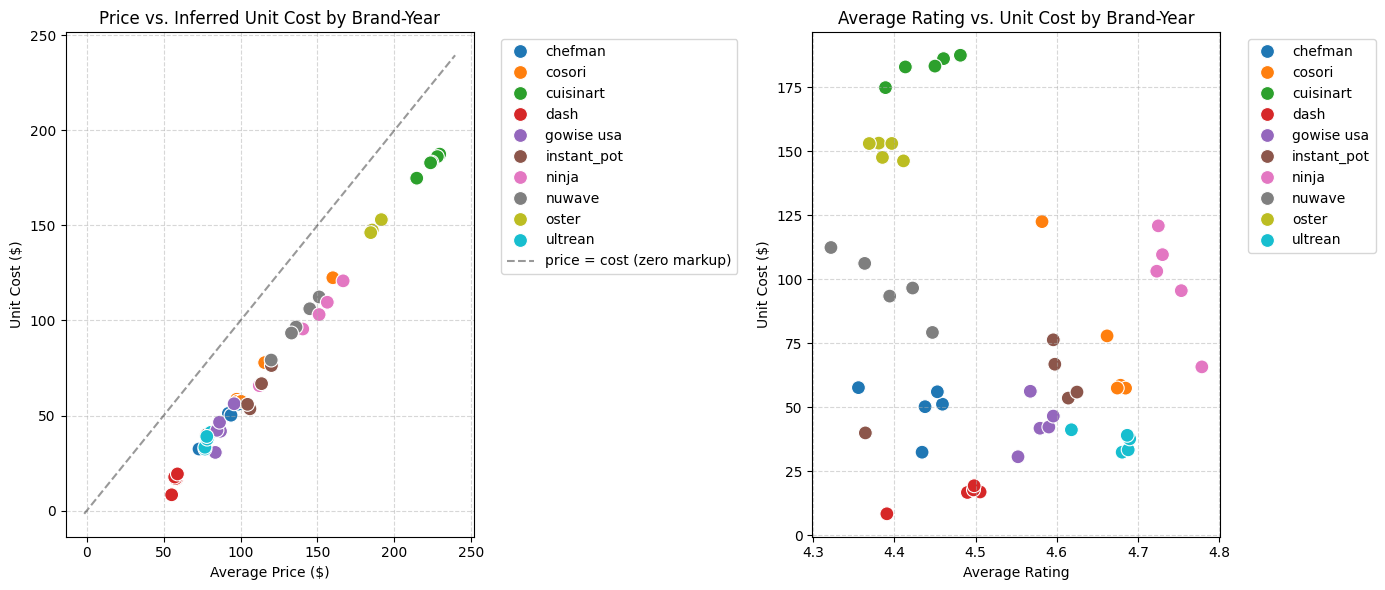

In [6]:
# Q3-3: Scatter plots — price vs. unit cost, and avg_rating vs. unit cost

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Price vs Unit Cost
sns.scatterplot(data=df, x='avg_price', y='unit_cost', hue='brand', s=100, ax=axes[0])
axes[0].set_title('Price vs. Inferred Unit Cost by Brand-Year')
axes[0].set_xlabel('Average Price ($)')
axes[0].set_ylabel('Unit Cost ($)')
lims = [min(df['avg_price'].min(), df['unit_cost'].min()) - 10,
        max(df['avg_price'].max(), df['unit_cost'].max()) + 10]
axes[0].plot(lims, lims, 'k--', alpha=0.4, label='price = cost (zero markup)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Rating vs Unit Cost
sns.scatterplot(data=df, x='avg_rating', y='unit_cost', hue='brand', s=100, ax=axes[1])
axes[1].set_title('Average Rating vs. Unit Cost by Brand-Year')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Unit Cost ($)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

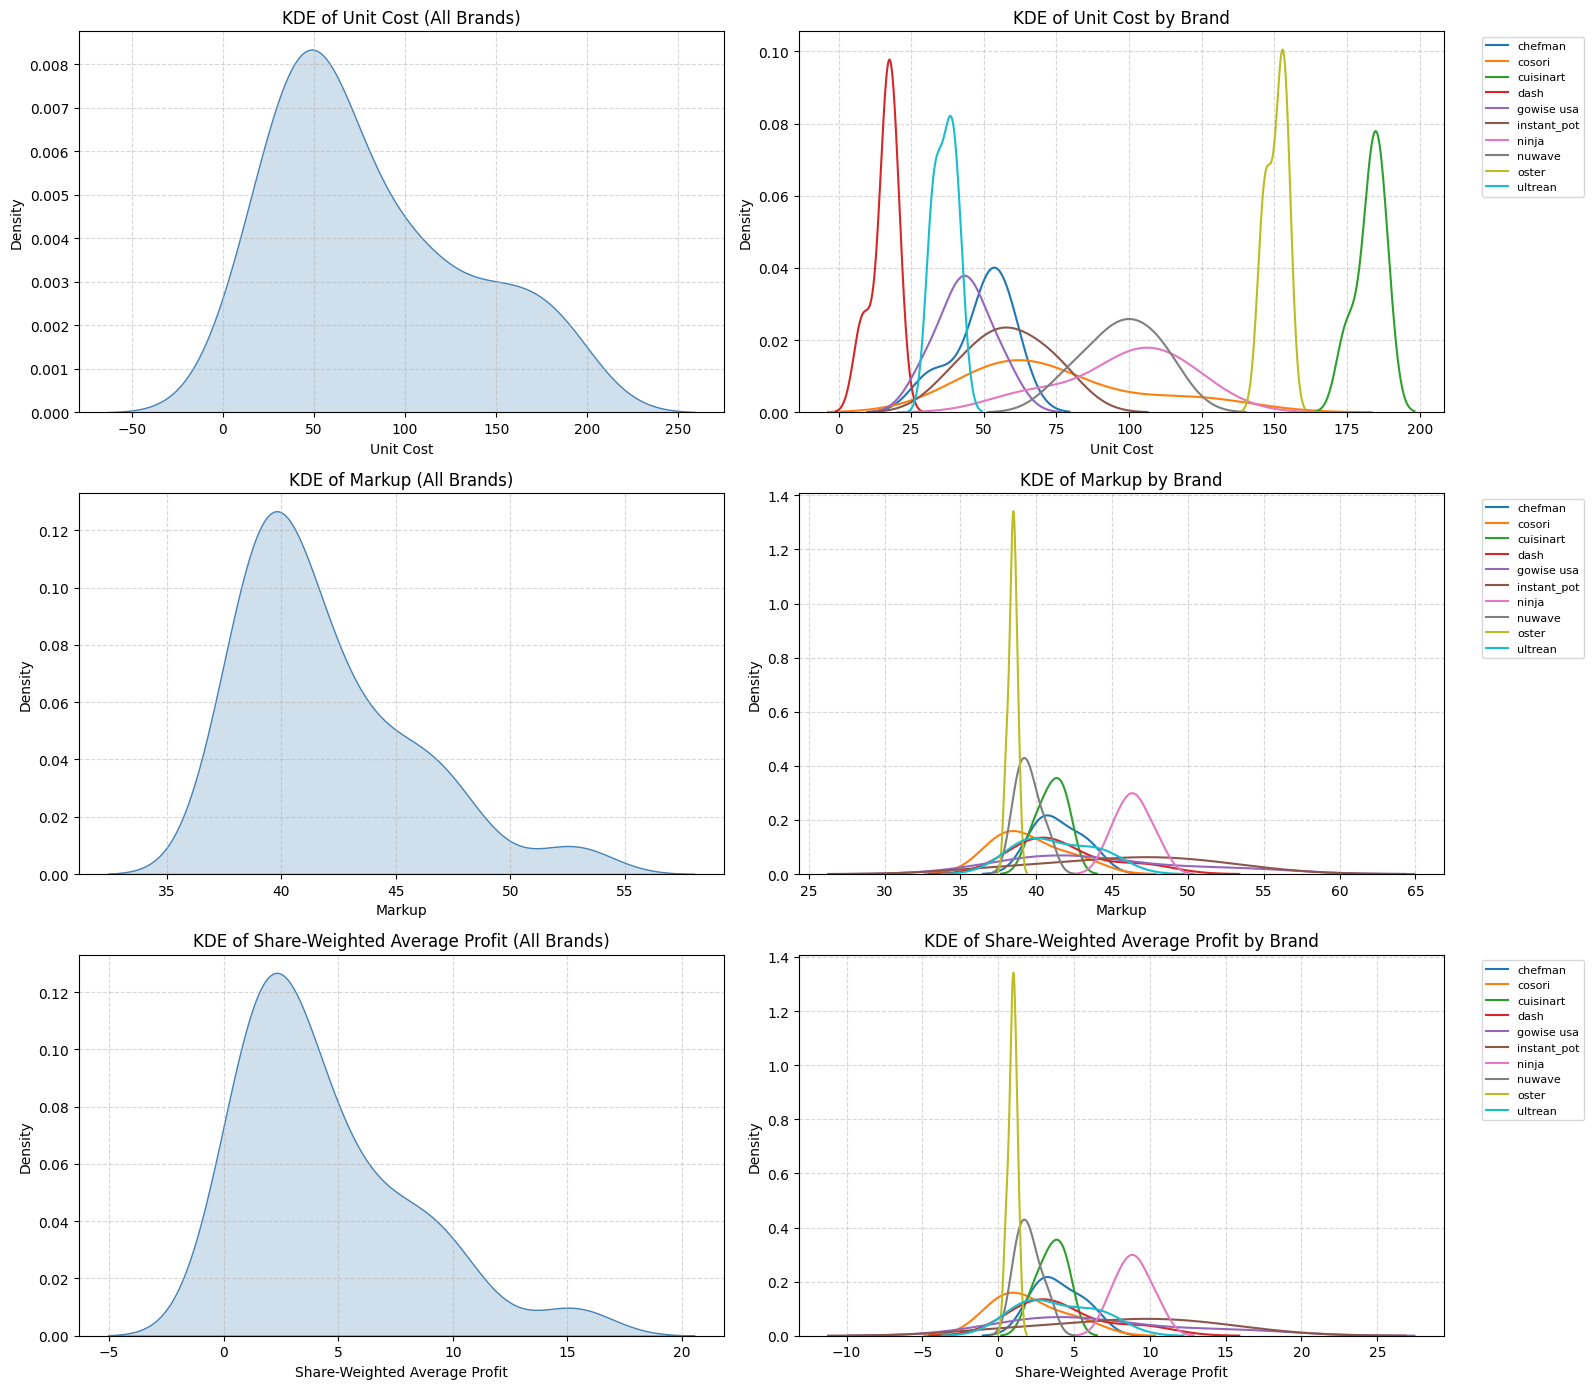

In [7]:
# Q3-4: KDE plots of unit costs, markups, and average profit — overall and by brand

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
variables = ['unit_cost', 'markup', 'average_profit']
titles    = ['Unit Cost', 'Markup', 'Share-Weighted Average Profit']

for i, (var, title) in enumerate(zip(variables, titles)):
    # Left: overall KDE
    sns.kdeplot(df[var], fill=True, ax=axes[i][0], color='steelblue')
    axes[i][0].set_title(f'KDE of {title} (All Brands)')
    axes[i][0].set_xlabel(title)
    axes[i][0].grid(True, linestyle='--', alpha=0.5)

    # Right: by brand
    for brand, grp in df.groupby('brand'):
        sns.kdeplot(grp[var], fill=False, label=brand, ax=axes[i][1])
    axes[i][1].set_title(f'KDE of {title} by Brand')
    axes[i][1].set_xlabel(title)
    axes[i][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[i][1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Share-Weighted Average Profit by Brand (higher = more profitable):
brand
ninja          8.9050
instant_pot    8.4873
gowise usa     6.5040
dash           4.2285
chefman        3.9836
ultrean        3.9269
cuisinart      3.5346
cosori         2.0287
nuwave         2.0093
oster          0.9579
Name: average_profit, dtype: float64


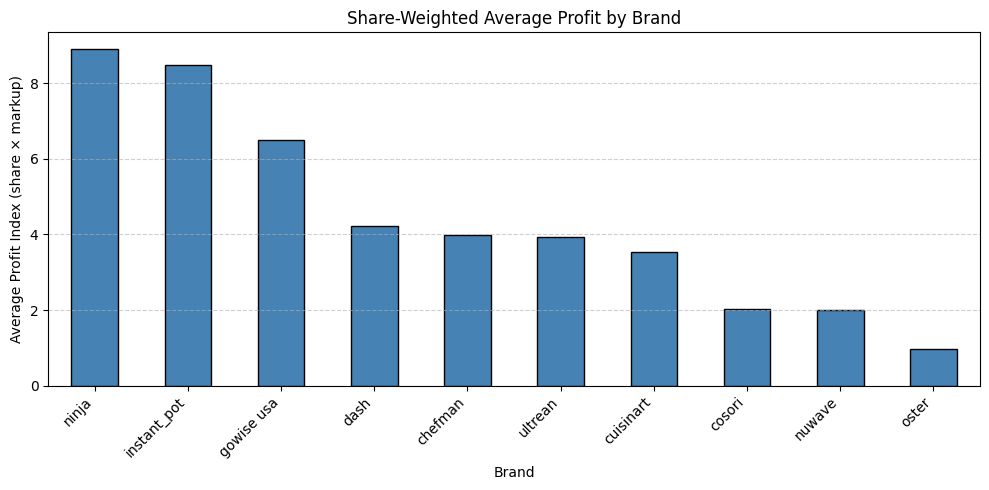

In [8]:
# Q3-5: Which brands have the highest share-weighted average profit?

profit_by_brand = df.groupby('brand')['average_profit'].mean().sort_values(ascending=False).round(4)
print("Share-Weighted Average Profit by Brand (higher = more profitable):")
print(profit_by_brand)

# Bar chart for easy visualization
plt.figure(figsize=(10, 5))
profit_by_brand.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Share-Weighted Average Profit by Brand')
plt.ylabel('Average Profit Index (share × markup)')
plt.xlabel('Brand')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Results

Submit a GitHub repo containing:

1. A notebook corresponding to the data analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
2. A notebook corresponding to the data scientist work, including the code and graphs, explicitly answering the questions above in text markdown chunks
3. A notebook corresponding to the pricing analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
4. A short presentation of your findings, about 5-8 slides.

Your presentation should be written as if you were giving market intelligence to a business audience. It should include:

- A short description of the air-fryer market
- A few plots showing prices, ratings, and market shares over time
- A short explanation of the demand model (multinomial logistic regression, estimated by linear regression on log market share)
- The estimated price coefficient and why its sign matters
- A discussion of the most important product features
- Estimated unit costs, markups, and share-weighted profits
- A conclusion about the brands' relative positions in the market

Do not fill slides with raw code. Use your code to produce clear tables and figures, then explain the market story in words.